# Modélisation — Système de recommandation

Comparaison de 3 approches :
1. **Baseline** — moyenne globale/par film
2. **Filtrage collaboratif** — similarité cosinus entre films (item-based)
3. **SVD** — factorisation matricielle (technique du Netflix Prize), via la librairie `surprise`

Évaluation en 2 temps : RMSE sur les notes prédites, puis Precision@K sur les recommandations elles-mêmes.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error, mean_absolute_error

train_ratings = pd.read_csv('../data/processed/train_ratings.csv')
test_ratings = pd.read_csv('../data/processed/test_ratings.csv')
movies = pd.read_csv('../data/movies.csv')

global_mean = train_ratings['rating'].mean()
movie_mean = train_ratings.groupby('movieId')['rating'].mean()

print(f"Train : {train_ratings.shape}, Test : {test_ratings.shape}")
print(f"Moyenne globale : {global_mean:.3f}")

Train : (80896, 4), Test : (19940, 4)
Moyenne globale : 3.503


## Approche 1 — Baseline (moyenne par film)

Pour chaque paire (utilisateur, film) du test, on prédit simplement la note moyenne de ce film (ou la moyenne globale si le film est inconnu du train). C'est le point de comparaison minimal : toute approche plus complexe doit faire mieux que ça pour être justifiée.

In [13]:
def predict_baseline(user_id, movie_id):
    if movie_id in movie_mean.index:
        return movie_mean[movie_id]
    return global_mean

test_ratings['pred_baseline'] = test_ratings.apply(
    lambda row: predict_baseline(row['userId'], row['movieId']), axis=1
)

rmse_baseline = np.sqrt(mean_squared_error(test_ratings['rating'], test_ratings['pred_baseline']))
mae_baseline = mean_absolute_error(test_ratings['rating'], test_ratings['pred_baseline'])

print(f"Baseline — RMSE : {rmse_baseline:.4f}, MAE : {mae_baseline:.4f}")

results = [{'model': 'Baseline (moyenne par film)', 'rmse': rmse_baseline, 'mae': mae_baseline}]

Baseline — RMSE : 0.9856, MAE : 0.7584


## Approche 2 — Filtrage collaboratif item-based (similarité cosinus)

Principe : deux films sont "similaires" si les utilisateurs qui les ont notés leur ont donné des notes proches. Pour prédire la note d'un utilisateur sur un film, on regarde comment il a noté les films les plus similaires.

In [14]:
# Matrice utilisateur-film (train), NaN remplacés par 0 pour le calcul de similarité
user_movie_matrix = train_ratings.pivot_table(index='userId', columns='movieId', values='rating')
user_movie_matrix_filled = user_movie_matrix.fillna(0)

# Similarité cosinus entre films (colonnes) → matrice film x film
movie_similarity = cosine_similarity(user_movie_matrix_filled.T)
movie_similarity_df = pd.DataFrame(
    movie_similarity,
    index=user_movie_matrix_filled.columns,
    columns=user_movie_matrix_filled.columns
)

print(f"Matrice de similarité film-film : {movie_similarity_df.shape}")

Matrice de similarité film-film : (8998, 8998)


In [15]:
def predict_item_based(user_id, movie_id, k=20):
    if movie_id not in movie_similarity_df.index or user_id not in user_movie_matrix.index:
        return global_mean

    user_ratings = user_movie_matrix.loc[user_id].dropna()
    if len(user_ratings) == 0:
        return global_mean

    # Similarités entre le film cible et les films déjà notés par l'utilisateur
    sims = movie_similarity_df.loc[movie_id, user_ratings.index]

    # On garde les k films les plus similaires ayant une similarité positive
    top_k = sims.sort_values(ascending=False).head(k)
    top_k = top_k[top_k > 0]

    if len(top_k) == 0:
        return movie_mean.get(movie_id, global_mean)

    weighted_sum = (top_k * user_ratings[top_k.index]).sum()
    sim_sum = top_k.sum()

    return weighted_sum / sim_sum if sim_sum > 0 else global_mean

# Test sur un échantillon (le calcul ligne par ligne sur tout le test set peut être lent)
sample_test = test_ratings.sample(n=min(3000, len(test_ratings)), random_state=42).copy()
sample_test['pred_item_based'] = sample_test.apply(
    lambda row: predict_item_based(row['userId'], row['movieId']), axis=1
)

rmse_item = np.sqrt(mean_squared_error(sample_test['rating'], sample_test['pred_item_based']))
mae_item = mean_absolute_error(sample_test['rating'], sample_test['pred_item_based'])

print(f"Filtrage collaboratif (item-based) — RMSE : {rmse_item:.4f}, MAE : {mae_item:.4f}")
print(f"(évalué sur un échantillon de {len(sample_test)} notes pour des raisons de temps de calcul)")

results.append({'model': 'Filtrage collaboratif (item-based)', 'rmse': rmse_item, 'mae': mae_item})

Filtrage collaboratif (item-based) — RMSE : 0.9048, MAE : 0.6899
(évalué sur un échantillon de 3000 notes pour des raisons de temps de calcul)


## Approche 3 — SVD (factorisation matricielle)

La technique qui a gagné le Netflix Prize : on décompose la matrice utilisateur-film creuse en deux matrices de facteurs latents plus petites (utilisateurs x facteurs, films x facteurs), qui capturent des dimensions cachées (genre préféré, style, etc.) sans qu'on ait à les définir manuellement.

In [ ]:
# Installation si besoin : décommenter la ligne suivante
import sys
!{sys.executable} -m pip install scikit-surprise

In [16]:
from surprise import Dataset, Reader, SVD
from surprise.accuracy import rmse as surprise_rmse, mae as surprise_mae

reader = Reader(rating_scale=(0.5, 5.0))

train_data = Dataset.load_from_df(train_ratings[['userId', 'movieId', 'rating']], reader)
trainset = train_data.build_full_trainset()

svd_model = SVD(n_factors=50, n_epochs=20, random_state=42)
svd_model.fit(trainset)

# Construction du testset au format attendu par surprise
testset = list(test_ratings[['userId', 'movieId', 'rating']].itertuples(index=False, name=None))
predictions = svd_model.test(testset)

rmse_svd = surprise_rmse(predictions, verbose=False)
mae_svd = surprise_mae(predictions, verbose=False)

print(f"SVD — RMSE : {rmse_svd:.4f}, MAE : {mae_svd:.4f}")

results.append({'model': 'SVD (factorisation matricielle)', 'rmse': rmse_svd, 'mae': mae_svd})

SVD — RMSE : 0.8806, MAE : 0.6742


## Comparaison des 3 approches

                                model      rmse       mae
2     SVD (factorisation matricielle)  0.880649  0.674224
1  Filtrage collaboratif (item-based)  0.904814  0.689865
0         Baseline (moyenne par film)  0.985587  0.758399


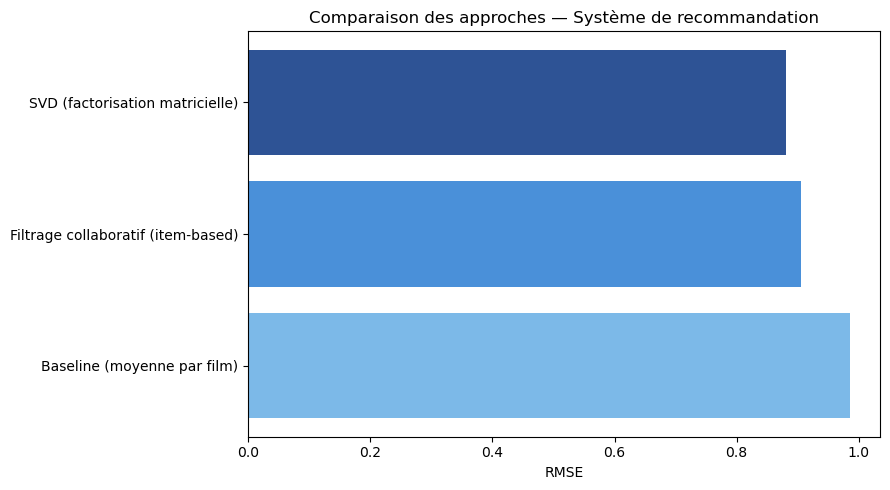

In [17]:
results_df = pd.DataFrame(results).sort_values('rmse')
print(results_df)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(results_df['model'], results_df['rmse'], color=['#2E5395', '#4A90D9', '#7CB9E8'])
ax.set_xlabel('RMSE')
ax.set_title('Comparaison des approches — Système de recommandation')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/model_comparison.png', dpi=150)
plt.show()

## Sauvegarde du modèle SVD (meilleur modèle attendu)

In [18]:
import joblib
import os

os.makedirs('../outputs/models', exist_ok=True)
joblib.dump(svd_model, '../outputs/models/svd_model.pkl')

print("Modèle SVD sauvegardé dans outputs/models/")

Modèle SVD sauvegardé dans outputs/models/
